HW 13

hw13作業請同學針對鐵達尼號沈船人員資料集，利用Logistic Regression、CART決策樹、及隨機森蓮模型進行人員存活預測分析。
1. 建立分類預測模型，計算評估效能，比較評估效能
2. 針對CART決策樹繪製樹圖
3. 以隨機森林模型計算特之因子重要性，並由大到小排序
4. 以隨機森林模型利用網格搜尋方法執行超參數分析（至少選３個特徵因子）

### 獲得鐵達尼資料

In [1]:
import pandas as pd
import kagglehub


# Download the latest version of a common Titanic dataset
path = kagglehub.dataset_download("yasserh/titanic-dataset")

# Load the CSV file (typically named 'Titanic-Dataset.csv' or similar)
# Adjust the filename based on the output of the list above
df = pd.read_csv(f"{path}/Titanic-Dataset.csv")
df.head()

d:\Anaconda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 22.0k/22.0k [00:00<00:00, 1.33MB/s]

Extracting files...


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,Model,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.815642,0.810345,0.681159,0.740157
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
1,CART Decision Tree,0.787709,0.844444,0.550725,0.666667


各模型分類報告：

===== Logistic Regression =====
Confusion Matrix:
[[98 12]
 [23 46]]
              precision    recall  f1-score   support

           0     0.8099    0.8909    0.8485       110
           1     0.7931    0.6667    0.7244        69

    accuracy                         0.8045       179
   macro avg     0.8015    0.7788    0.7864       179
weighted avg     0.8034    0.8045    0.8007       179


===== CART Decision Tree =====
Confusion Matrix:
[[103   7]
 [ 31  38]]
              precision    recall  f1-score   support

           0     0.7687    0.9364    0.8443       110
           1     0.8444    0.5507    0.6667        69

    accuracy                         0.7877       179
   macro avg     0.8066    0.7435    0.7555       179
weighted avg     0.7979    0.7877    0.7758       179


===== Random Forest =====
Confusion Matrix:
[[99 11]
 [22 47]]
              precision    recall  f1-score   support

           0     0.8182    0.9000    0.8571       110
           1     0.81

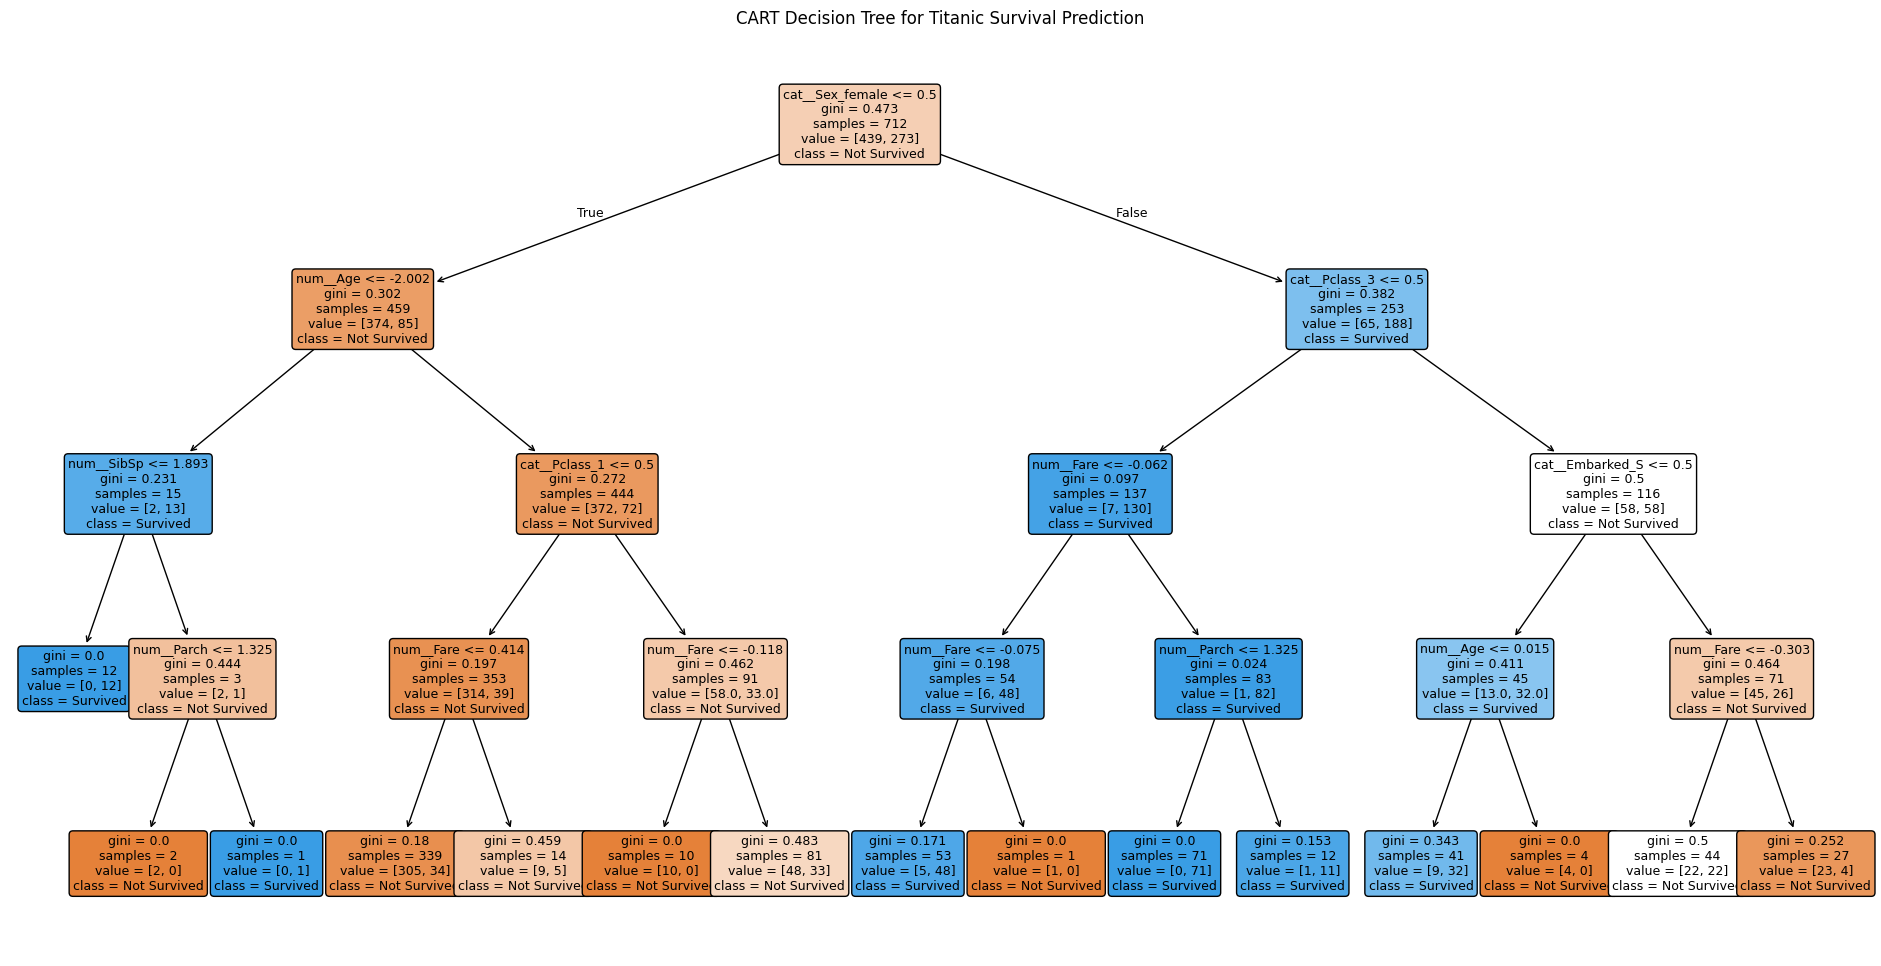

,Feature,Importance
3,num__Fare,0.251890
0,num__Age,0.243494
8,cat__Sex_male,0.159184
7,cat__Sex_female,0.125167
6,cat__Pclass_3,0.051746
1,num__SibSp,0.046266
2,num__Parch,0.038237
4,cat__Pclass_1,0.031493
11,cat__Embarked_S,0.017317
5,cat__Pclass_2,0.015988


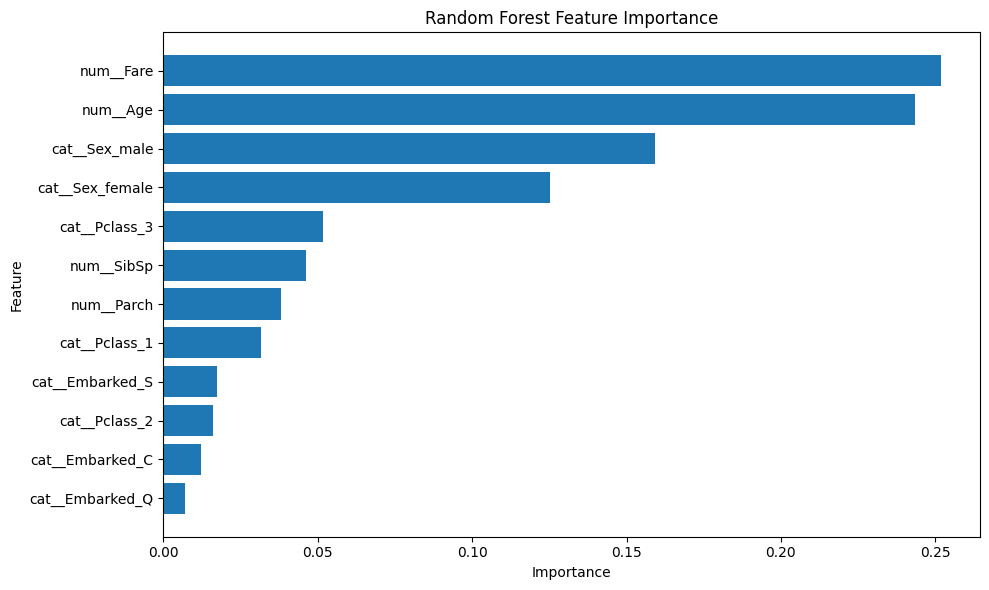

Random Forest Grid Search 最佳參數：
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
交叉驗證最佳 F1-score：0.7600

最佳 Random Forest 在測試集上的表現：
Accuracy: 0.8156
Precision: 0.8333
Recall: 0.6522
F1-score: 0.7317

Classification Report:
              precision    recall  f1-score   support

           0     0.8080    0.9182    0.8596       110
           1     0.8333    0.6522    0.7317        69

    accuracy                         0.8156       179
   macro avg     0.8207    0.7852    0.7956       179
weighted avg     0.8178    0.8156    0.8103       179



,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,mean_test_score,rank_test_score
63,100,None,2,2,0.759960,1
68,300,None,5,2,0.759168,2
64,200,None,2,2,0.759032,3
65,300,None,2,2,0.755274,4
60,100,None,10,1,0.754694,5
66,100,None,5,2,0.754361,6
67,200,None,5,2,0.752886,7
62,300,None,10,1,0.752611,8
61,200,None,10,1,0.750843,9
70,200,None,10,2,0.749309,10


In [2]:
# HW13：鐵達尼號存活預測分析
# 使用 Logistic Regression、CART 決策樹與 Random Forest 進行分類預測、模型評估、樹圖繪製、特徵重要性與網格搜尋

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. 資料前處理
# 選擇可用於預測的特徵欄位，排除 PassengerId、Name、Ticket、Cabin 等識別性或缺失過多欄位
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = df[features]
y = df[target]

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. 建立三種分類模型
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'CART Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
    ])
}

# 3. 模型訓練、預測與效能評估
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by='F1-score', ascending=False)
display(results_df)

print('各模型分類報告：')
for name, model in trained_models.items():
    print(f'\n===== {name} =====')
    y_pred = model.predict(X_test)
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))

# 4. CART 決策樹繪製樹圖
cart_model = trained_models['CART Decision Tree']
cart_preprocessor = cart_model.named_steps['preprocessor']
cart_classifier = cart_model.named_steps['classifier']

feature_names = cart_preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    cart_classifier,
    feature_names=feature_names,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('CART Decision Tree for Titanic Survival Prediction')
plt.show()

# 5. 隨機森林特徵重要性，並由大到小排序
rf_model = trained_models['Random Forest']
rf_preprocessor = rf_model.named_steps['preprocessor']
rf_classifier = rf_model.named_steps['classifier']

rf_feature_names = rf_preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

# 6. 隨機森林模型網格搜尋超參數分析（至少三個超參數）
rf_grid_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Random Forest Grid Search 最佳參數：')
print(grid_search.best_params_)
print(f'交叉驗證最佳 F1-score：{grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

print('\n最佳 Random Forest 在測試集上的表現：')
print(f'Accuracy: {accuracy_score(y_test, best_rf_pred):.4f}')
print(f'Precision: {precision_score(y_test, best_rf_pred):.4f}')
print(f'Recall: {recall_score(y_test, best_rf_pred):.4f}')
print(f'F1-score: {f1_score(y_test, best_rf_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, best_rf_pred, digits=4))

# 顯示網格搜尋結果前 10 名
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df = cv_results_df[[
    'param_classifier__n_estimators',
    'param_classifier__max_depth',
    'param_classifier__min_samples_split',
    'param_classifier__min_samples_leaf',
    'mean_test_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

display(cv_results_df.head(10))